<a href="https://colab.research.google.com/github/soonyz06/Factor_Tangency/blob/main/Factor_Tangency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We test whether allocation/timing improves as richer information and conditioning are introduced. An **information ladder** compares equal weight, directional mean, mean weighting, inverse volatility, directional inverse volatility, Sharpe weighting, and MVO. A parallel **conditioning ladder** applies these rules using trailing five-year or HMM-conditioned moments. Portfolios rebalance monthly, use Ledoit–Wolf covariance, common gross-exposure constraints, and factor-level turnover costs. Meta-MVO portfolios combine trailing strategies alone or the full trailing-plus-HMM set. Performance is compared on identical OOS dates using standard return and risk metrics and stationary-block-bootstrap Sharpe distributions.


In [12]:
import pandas as pd
import numpy as np
#!pip install hmmlearn

# Complete Portfolio

,CAGR,Arithmetic Return,Volatility,Sharpe,Skew,Max Drawdown
Trailing Equal Weight,0.0573,0.0603,0.0962,0.6272,0.0395,-0.3040
Trailing Direction EW,0.0630,0.0758,0.1715,0.4421,0.1222,-0.5497
Trailing Mu Weight,0.0614,0.0645,0.0989,0.6523,0.0776,-0.2202
Trailing IV,0.0457,0.0502,0.1049,0.4782,0.2469,-0.4109
Trailing Direction IV,0.0439,0.0482,0.1017,0.4736,0.3115,-0.4087
Trailing Sharpe Weight,0.0592,0.0618,0.0922,0.6695,-0.0755,-0.2448
Trailing MVO,0.0486,0.0550,0.1228,0.4485,-0.1872,-0.3211
HMM Direction EW,0.0632,0.0698,0.1306,0.5350,-0.1701,-0.4848
HMM Mu Weight,0.0498,0.0524,0.0869,0.6028,-0.2627,-0.3086
HMM IV,0.0524,0.0555,0.0939,0.5909,-0.3849,-0.3436


,Gross Sharpe,Net Sharpe,Avg Monthly SPY Turnover,Annualized SPY Turnover,Annualized Trading Cost,Average SPY Exposure
Trailing Equal Weight,0.6272,0.6272,0.0000,0.0000,0.0000,0.5000
Trailing Direction EW,0.4432,0.4421,0.0303,0.3643,0.0002,0.8395
Trailing Mu Weight,0.6553,0.6523,0.0489,0.5877,0.0003,0.4998
Trailing IV,0.4791,0.4782,0.0167,0.2005,0.0001,0.4447
Trailing Direction IV,0.4748,0.4736,0.0210,0.2525,0.0001,0.4018
Trailing Sharpe Weight,0.6725,0.6695,0.0455,0.5473,0.0003,0.4693
Trailing MVO,0.4501,0.4485,0.0336,0.4044,0.0002,0.5565
HMM Direction EW,0.5472,0.5350,0.2667,3.2060,0.0016,0.7294
HMM Mu Weight,0.6221,0.6028,0.2820,3.3901,0.0017,0.5017
HMM IV,0.6046,0.5909,0.2156,2.5925,0.0013,0.6002


,CAGR,Arithmetic Return,Volatility,Sharpe,Skew,Max Drawdown
HMM21 Direction EW,0.0658,0.0732,0.1377,0.5316,-0.1461,-0.4336
HMM21 Mu Weight,0.0504,0.0527,0.0840,0.6273,-0.3354,-0.2367
HMM21 IV,0.0501,0.0532,0.0927,0.5737,-0.4036,-0.3031
HMM21 Direction IV,0.0489,0.0511,0.0821,0.6225,-0.4858,-0.2070
HMM21 Sharpe Weight,0.0497,0.0520,0.0840,0.6192,-0.3979,-0.2310
HMM21 MVO,0.0514,0.0549,0.0974,0.5636,-0.4882,-0.2844


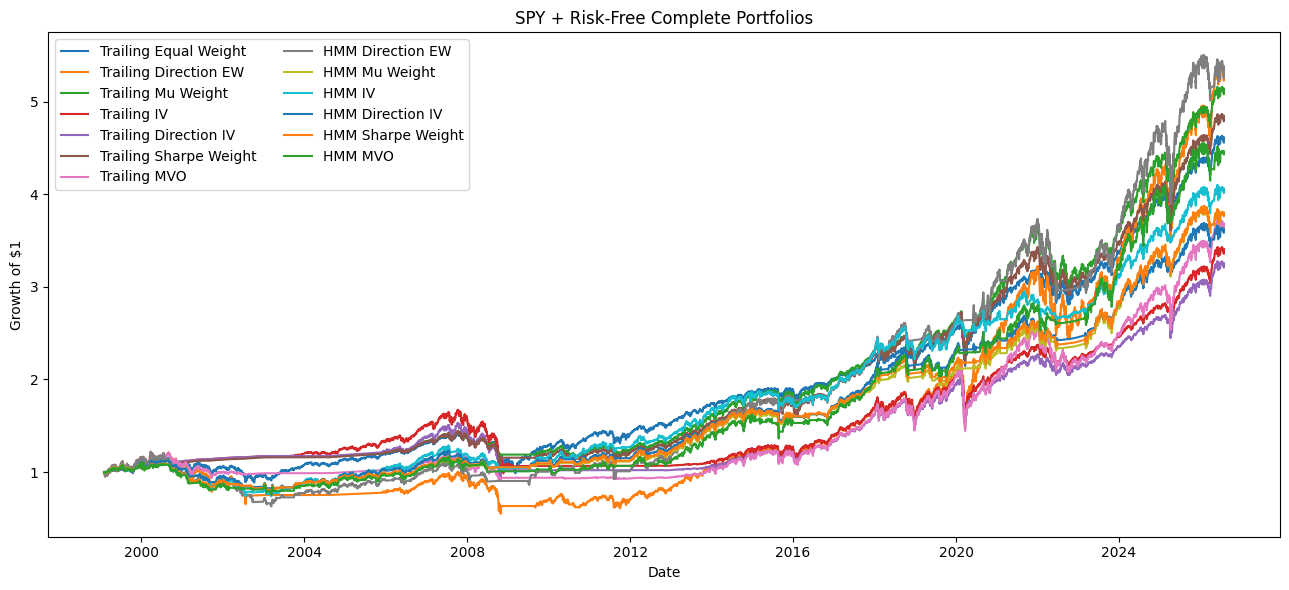

,Observed,Bootstrap Mean,2.5%,Median,97.5%,P(S > 0)
Trailing Equal Weight,0.6272,0.6352,0.3057,0.6311,0.9902,0.9998
Trailing Direction EW,0.4421,0.4490,0.1182,0.4464,0.7920,0.9956
Trailing Mu Weight,0.6523,0.6583,0.3310,0.6551,0.9955,1.0000
Trailing IV,0.4782,0.4961,0.1361,0.4868,0.8861,0.9966
Trailing Direction IV,0.4736,0.4919,0.1311,0.4838,0.8833,0.9968
Trailing Sharpe Weight,0.6695,0.6768,0.3389,0.6726,1.0298,1.0000
Trailing MVO,0.4485,0.4570,0.1294,0.4551,0.8012,0.9968
HMM Direction EW,0.5350,0.5383,0.2010,0.5340,0.8867,0.9990
HMM Mu Weight,0.6028,0.6064,0.2763,0.6062,0.9483,1.0000
HMM IV,0.5909,0.5943,0.2419,0.5941,0.9447,0.9998


In [16]:
import yfinance as yf
from sklearn.covariance import LedoitWolf
from scipy.stats import skew, multivariate_normal
from scipy.special import logsumexp

CP_GAMMA=5.0
CP_TC_BPS=5.0
CP_MIN_SCALE_MONTHS=12

z=df.copy()
if "date" in z.columns:
    z["date"]=pd.to_datetime(z["date"])
    z=z.set_index("date")
z.index=pd.to_datetime(z.index)

rf=pd.to_numeric(z["RF"],errors="coerce").sort_index()
if RETURNS_ARE_PERCENT:
    rf=rf/100

d=yf.download(
    "SPY",
    start=(rf.index.min()-pd.Timedelta(days=10)).strftime("%Y-%m-%d"),
    end=(rf.index.max()+pd.Timedelta(days=2)).strftime("%Y-%m-%d"),
    auto_adjust=True,
    progress=False
)

if isinstance(d.columns,pd.MultiIndex):
    px=d["Close"]["SPY"]
else:
    px=d["Close"]

spy=px.pct_change(fill_method=None)
cp=pd.concat([spy.rename("SPY"),rf.rename("RF")],axis=1).dropna()
cp["EX"]=cp["SPY"]-cp["RF"]

def cp_lw(a):
    a=np.asarray(a).reshape(-1,1)
    return LedoitWolf().fit(a).covariance_[0,0]

def cp_fit_hmm(hist):
    a=np.asarray(hist).reshape(-1,1)
    m=a.mean(0)
    s=a.std(0,ddof=1)
    s=np.where(s>0,s,1)
    X=(a-m)/s

    model=GaussianHMM(
        n_components=HMM_STATES,
        covariance_type="full",
        n_iter=HMM_N_ITER,
        random_state=SEED
    ).fit(X)

    gamma=model.predict_proba(X)
    lab=gamma.argmax(1)
    gv=cp_lw(a)
    means=[]
    vars=[]

    for k in range(HMM_STATES):
        ak=a[lab==k,0]
        if len(ak)>=3:
            means.append(ak.mean())
            vars.append(cp_lw(ak))
        else:
            means.append(a[:,0].mean())
            vars.append(gv)

    return {
        "model":model,
        "alpha":gamma[-1],
        "mean":m,
        "sd":s,
        "means":np.asarray(means),
        "vars":np.asarray(vars)
    }

def cp_update_hmm(state,x):
    model=state["model"]
    q=(np.asarray([x])-state["mean"])/state["sd"]
    prior=state["alpha"]@model.transmat_
    ll=np.asarray([
        multivariate_normal.logpdf(
            q,
            mean=model.means_[k],
            cov=model.covars_[k],
            allow_singular=True
        )
        for k in range(HMM_STATES)
    ])
    lp=np.log(np.clip(prior,1e-300,None))+ll
    state["alpha"]=np.exp(lp-logsumexp(lp))

def cp_hmm_fc(state,h):
    p=state["alpha"].copy()
    mus=[]
    sec=[]

    for _ in range(h):
        p=p@state["model"].transmat_
        mu=p@state["means"]
        second=p@(state["vars"]+state["means"]**2)
        mus.append(mu)
        sec.append(second)

    mu=np.mean(mus)
    var=max(np.mean(sec)-mu**2,1e-12)
    return mu,var

def cp_pct(x,hist):
    h=np.asarray(hist,dtype=float)
    h=h[np.isfinite(h)]
    if len(h)<CP_MIN_SCALE_MONTHS:
        return np.nan
    return (np.sum(h<x)+0.5*np.sum(h==x)+0.5)/(len(h)+1)

def cp_weights(mu,var,hist):
    sd=np.sqrt(max(var,1e-12))
    raw={
        "Mu Weight":mu,
        "IV":1/sd,
        "Direction IV":1/sd,
        "Sharpe Weight":mu/sd
    }

    y={
        "Equal Weight":0.5,
        "Direction EW":float(mu>0),
        "Mu Weight":0 if mu<=0 else cp_pct(mu,hist["Mu Weight"]),
        "IV":cp_pct(1/sd,hist["IV"]),
        "Direction IV":0 if mu<=0 else cp_pct(1/sd,hist["Direction IV"]),
        "Sharpe Weight":0 if mu<=0 else cp_pct(mu/sd,hist["Sharpe Weight"]),
        "MVO":np.clip(mu/(CP_GAMMA*var),0,1)
    }

    for k,v in raw.items():
        hist[k].append(v)

    return y

BASE=[
    "Equal Weight",
    "Direction EW",
    "Mu Weight",
    "IV",
    "Direction IV",
    "Sharpe Weight",
    "MVO"
]

TRAIL=["Trailing "+s for s in BASE]
HMM=["HMM "+s for s in BASE[1:]]
HMM21=["HMM21 "+s for s in BASE[1:]]

STRATS=TRAIL+HMM

gross=pd.DataFrame(np.nan,index=cp.index,columns=STRATS)
gross21=pd.DataFrame(np.nan,index=cp.index,columns=HMM21)
expo=pd.DataFrame(np.nan,index=cp.index,columns=STRATS)
expo21=pd.DataFrame(np.nan,index=cp.index,columns=HMM21)

th={k:[] for k in ["Mu Weight","IV","Direction IV","Sharpe Weight"]}
hh={k:[] for k in ["Mu Weight","IV","Direction IV","Sharpe Weight"]}
h21={k:[] for k in ["Mu Weight","IV","Direction IV","Sharpe Weight"]}

periods=cp.index.to_period("M")
state=None
lastq=None

for month in sorted(periods.unique()):
    dates=cp.index[periods==month]
    if len(dates)==0:
        continue

    p=cp.index.get_loc(dates[0])
    if p==0:
        continue

    info=cp.index[p-1]
    hist=cp["EX"].loc[:info].tail(TRAIL_DAYS)

    if len(hist)>=TRAIL_DAYS:
        mu=hist.mean()
        var=cp_lw(hist.values)
        Y=cp_weights(mu,var,th)

        for s in BASE:
            name="Trailing "+s
            y=Y[s]
            expo.loc[dates,name]=y
            gross.loc[dates,name]=cp.loc[dates,"RF"]+y*cp.loc[dates,"EX"]

    q=(month.year,month.quarter)

    if q!=lastq and len(hist)>=HMM_WINDOW:
        state=cp_fit_hmm(hist.tail(HMM_WINDOW))
        lastq=q

    if state is not None:
        mu,var=cp_hmm_fc(state,1)
        mu21,var21=cp_hmm_fc(state,21)

        Y=cp_weights(mu,var,hh)
        Y21=cp_weights(mu21,var21,h21)

        for s in BASE[1:]:
            name="HMM "+s
            y=Y[s]
            expo.loc[dates,name]=y
            gross.loc[dates,name]=cp.loc[dates,"RF"]+y*cp.loc[dates,"EX"]

            name21="HMM21 "+s
            y21=Y21[s]
            expo21.loc[dates,name21]=y21
            gross21.loc[dates,name21]=cp.loc[dates,"RF"]+y21*cp.loc[dates,"EX"]

        for x in cp.loc[dates,"EX"]:
            cp_update_hmm(state,x)

def cp_costs(gross,expo):
    cost=pd.DataFrame(0.0,index=gross.index,columns=gross.columns)
    turnover=pd.DataFrame(0.0,index=gross.index,columns=gross.columns)

    for s in gross.columns:
        prev=0.0

        for month in sorted(gross.index.to_period("M").unique()):
            dates=gross.index[gross.index.to_period("M")==month]
            y=expo.loc[dates,s].dropna()

            if y.empty:
                continue

            cur=y.iloc[0]
            t=abs(cur-prev)

            turnover.loc[dates[0],s]=t
            cost.loc[dates[0],s]=t*CP_TC_BPS/1e4
            prev=cur

    return gross-cost,turnover,cost

net,turn,cost=cp_costs(gross,expo)
net21,turn21,cost21=cp_costs(gross21,expo21)

common=gross[STRATS].dropna().index

G=gross.loc[common,STRATS]
N=net.loc[common,STRATS]
T=turn.loc[common,STRATS]
C=cost.loc[common,STRATS]

res=pd.DataFrame({s:met(N[s]) for s in STRATS}).T
gres=pd.DataFrame({s:met(G[s]) for s in STRATS}).T

years=len(common)/252
months=common.to_period("M").nunique()

cost_summary=pd.DataFrame({
    "Gross Sharpe":gres["Sharpe"],
    "Net Sharpe":res["Sharpe"],
    "Avg Monthly SPY Turnover":T.sum()/months,
    "Annualized SPY Turnover":T.sum()/years,
    "Annualized Trading Cost":C.sum()/years,
    "Average SPY Exposure":expo.loc[common,STRATS].mean()
})

display(res.round(4))
display(cost_summary.round(4))

rob_common=gross21[HMM21].dropna().index.intersection(common)
rob=pd.DataFrame({
    s:met(net21.loc[rob_common,s])
    for s in HMM21
}).T
display(rob.round(4))

wealth=(1+N).cumprod()

plt.figure(figsize=(13,6))
for s in STRATS:
    plt.plot(wealth.index,wealth[s],label=s)
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.title("SPY + Risk-Free Complete Portfolios")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

rng=np.random.default_rng(SEED)
A=N.values
boot=np.empty((N_BOOT,len(STRATS)))

for b in range(N_BOOT):
    ii=sb(len(A),BLOCK_LENGTH,rng)
    z=A[ii]

    for j in range(len(STRATS)):
        boot[b,j]=sr(z[:,j])

boot=pd.DataFrame(boot,columns=STRATS)

bs=pd.DataFrame({
    "Observed":res["Sharpe"],
    "Bootstrap Mean":boot.mean(),
    "2.5%":boot.quantile(.025),
    "Median":boot.median(),
    "97.5%":boot.quantile(.975),
    "P(S > 0)":(boot>0).mean()
})

display(bs.round(4))

#FF6 Rotation

,CAGR,Arithmetic Return,Volatility,Sharpe,Skew,Max Drawdown
Equal Weight,0.0421,0.0419,0.0360,1.1636,-0.7064,-0.1288
Trailing Direction EW,0.0300,0.0306,0.0459,0.6664,-0.7480,-0.1867
Trailing Mu Weight,0.0354,0.0371,0.0689,0.5391,-0.8972,-0.3218
Trailing IV,0.0377,0.0376,0.0325,1.1564,-0.4891,-0.1319
Trailing Direction IV,0.0270,0.0274,0.0378,0.7253,-0.4770,-0.1604
Trailing Sharpe Weight,0.0322,0.0332,0.0556,0.5980,-0.7090,-0.1960
Trailing MVO,0.0268,0.0271,0.0350,0.7738,-0.4306,-0.1128
HMM Direction EW,0.0109,0.0120,0.0484,0.2478,-0.5447,-0.2592
HMM Mu Weight,0.0225,0.0250,0.0748,0.3345,-0.9379,-0.4112
HMM IV,0.0373,0.0371,0.0321,1.1555,-0.4921,-0.1311


,Gross Sharpe,Net Sharpe,Avg Monthly Turnover,Annualized Turnover,Annualized Trading Cost
Equal Weight,1.1636,1.1636,0.0000,0.0000,0.0000
Trailing Direction EW,0.6838,0.6664,0.0674,0.8091,0.0008
Trailing Mu Weight,0.5601,0.5391,0.1208,1.4493,0.0014
Trailing IV,1.1587,1.1564,0.0062,0.0743,0.0001
Trailing Direction IV,0.7489,0.7253,0.0748,0.8979,0.0009
Trailing Sharpe Weight,0.6239,0.5980,0.1203,1.4431,0.0014
Trailing MVO,0.8096,0.7738,0.1049,1.2589,0.0013
HMM Direction EW,0.3617,0.2478,0.4586,5.5021,0.0055
HMM Mu Weight,0.4419,0.3345,0.6693,8.0309,0.0080
HMM IV,1.1734,1.1555,0.0482,0.5787,0.0006


,CAGR,Arithmetic Return,Volatility,Sharpe,Skew,Max Drawdown
HMM21 Direction EW,0.0206,0.0216,0.0496,0.4357,-0.6854,-0.2056
HMM21 Mu Weight,0.0312,0.0335,0.0736,0.4548,-1.0059,-0.3293
HMM21 IV,0.0372,0.0370,0.0322,1.1508,-0.4882,-0.1318
HMM21 Direction IV,0.0190,0.0196,0.0414,0.4745,-0.7475,-0.2124
HMM21 Sharpe Weight,0.0297,0.0310,0.0588,0.5267,-0.7158,-0.2409
HMM21 MVO,0.0206,0.0210,0.0349,0.6023,-0.6018,-0.2025


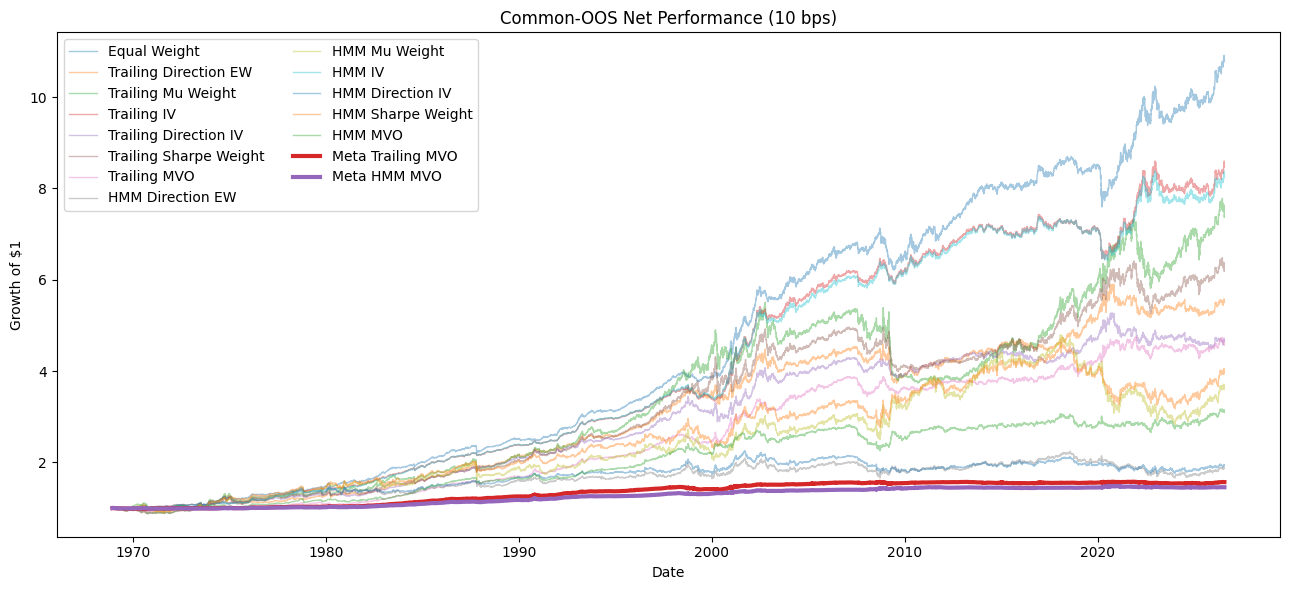

,Observed,Bootstrap Mean,2.5%,Median,97.5%,P(S > 0)
Equal Weight,1.1636,1.1658,0.8434,1.1624,1.4924,1.0000
Trailing Direction EW,0.6664,0.6702,0.3788,0.6689,0.9763,1.0000
Trailing Mu Weight,0.5391,0.5439,0.2502,0.5452,0.8397,0.9998
Trailing IV,1.1564,1.1560,0.8465,1.1526,1.4656,1.0000
Trailing Direction IV,0.7253,0.7289,0.4224,0.7260,1.0444,1.0000
Trailing Sharpe Weight,0.5980,0.6029,0.3060,0.6005,0.9062,0.9998
Trailing MVO,0.7738,0.7774,0.4688,0.7764,1.0893,1.0000
HMM Direction EW,0.2478,0.2489,-0.0377,0.2484,0.5294,0.9548
HMM Mu Weight,0.3345,0.3356,0.0669,0.3326,0.6059,0.9922
HMM IV,1.1555,1.1550,0.8413,1.1507,1.4680,1.0000


In [14]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import skew, multivariate_normal
from scipy.special import logsumexp
from sklearn.covariance import LedoitWolf
from hmmlearn.hmm import GaussianHMM

df = pd.read_csv("F-F_Research_Data_5_Factors_2x3_daily.csv", skiprows=4, skipfooter=2, engine="python")
df = df.rename(columns={df.columns[0]:"date"})
df["date"] = pd.to_datetime(df["date"], format="%Y%m%d")

df2 = pd.read_csv("F-F_Momentum_Factor_daily.csv", skiprows=13, skipfooter=2, engine="python")
df2 = df2.rename(columns={df2.columns[0]:"date"})
df2["date"] = pd.to_datetime(df2["date"], format="%Y%m%d")
df = df.merge(df2, on="date", how="inner").dropna().set_index('date') #no null

FACTOR_COLS=["Mkt-RF","SMB","HML","RMW","CMA","Mom"]
RETURNS_ARE_PERCENT=True
TRAIL_DAYS=HMM_WINDOW=META_WINDOW_DAYS=252*5
HMM_STATES,HMM_N_ITER,HMM_PRIMARY,HMM_ROBUST=3,500,1,21
META_MIN_DAYS,N_BOOT,BLOCK_LENGTH,SEED=63,5000,20,42
TRADING_COST_BPS=10.0

x=df.copy()
if "date" in x:
    x["date"]=pd.to_datetime(x["date"]); x=x.set_index("date")
x.index=pd.to_datetime(x.index)
r=x[FACTOR_COLS].apply(pd.to_numeric,errors="coerce").sort_index().dropna()
if RETURNS_ARE_PERCENT:r/=100
HAS_FUTURES_MAP="factor_futures_weights" in globals()

def l1(w):
    w=np.asarray(w,float); d=np.abs(w).sum(); return w/d if d else np.zeros_like(w)
def iv(sd): return l1(np.divide(1.0,sd,out=np.zeros_like(sd,float),where=np.asarray(sd)>0))
def dew(mu): return l1(np.sign(mu))
def muw(mu): return l1(mu)
def div(mu,sd): return l1(np.divide(np.sign(mu),sd,out=np.zeros_like(sd,float),where=np.asarray(sd)>0))
def sw(mu,sd): return l1(np.divide(mu,sd,out=np.zeros_like(sd,float),where=np.asarray(sd)>0))
def lw(a): return LedoitWolf().fit(np.asarray(a,float)).covariance_
def mvo(mu,cov): return l1(np.linalg.pinv(cov)@mu)
def met(z):
    z=pd.Series(z).dropna(); ar=z.mean()*252; v=z.std()*np.sqrt(252); w=(1+z).cumprod(); y=len(z)/252; dd=w/w.cummax()-1
    return pd.Series({"CAGR":w.iloc[-1]**(1/y)-1,"Arithmetic Return":ar,"Volatility":v,"Sharpe":ar/v if v else np.nan,"Skew":skew(z,bias=False),"Max Drawdown":dd.min()})
def sb(T,L,g):
    p=1/L; q=np.empty(T,int); q[0]=g.integers(T)
    for t in range(1,T):q[t]=g.integers(T) if g.random()<p else (q[t-1]+1)%T
    return q
def sr(z):
    s=np.std(z,ddof=1); return np.mean(z)/s*np.sqrt(252) if s else np.nan
def fmap(month,w):
    w=pd.Series(np.asarray(w,float),index=FACTOR_COLS)
    if not HAS_FUTURES_MAP:return w
    M=factor_futures_weights.get(month)
    if M is None:return None
    M=M.reindex(FACTOR_COLS).fillna(0.0)
    return pd.Series(w.values@M.values,index=M.columns,dtype=float)

def fit_hmm(hist):
    a=hist.values; mean=a.mean(0); sd=a.std(0,ddof=1); sd=np.where(sd>0,sd,1); X=(a-mean)/sd
    model=GaussianHMM(n_components=HMM_STATES,covariance_type="full",n_iter=HMM_N_ITER,random_state=SEED).fit(X)
    gamma=model.predict_proba(X); lab=gamma.argmax(1); gc=lw(a); means=[]; covs=[]
    for k in range(HMM_STATES):
        wk=gamma[:,k]; means.append(np.average(a,axis=0,weights=wk))
        ak=a[lab==k]; covs.append(lw(ak) if len(ak)>len(FACTOR_COLS)+1 else gc)
    return {"model":model,"alpha":gamma[-1],"mean":mean,"sd":sd,"means":np.asarray(means),"covs":np.asarray(covs)}
def update_hmm(s,obs):
    m=s["model"]; z=(obs-s["mean"])/s["sd"]; p=s["alpha"]@m.transmat_
    ll=np.array([multivariate_normal.logpdf(z,mean=m.means_[k],cov=m.covars_[k],allow_singular=True) for k in range(HMM_STATES)])
    q=np.log(np.clip(p,1e-300,None))+ll; s["alpha"]=np.exp(q-logsumexp(q))
def hmm_fc(s,h):
    p=s["alpha"].copy(); mus=[]; secs=[]
    for _ in range(h):
        p=p@s["model"].transmat_; mu=(p[:,None]*s["means"]).sum(0); sec=sum(p[k]*(s["covs"][k]+np.outer(s["means"][k],s["means"][k])) for k in range(HMM_STATES)); mus.append(mu); secs.append(sec)
    mu=np.mean(mus,0); cov=np.mean(secs,0)-np.outer(mu,mu); return mu,(cov+cov.T)/2

NON=["Equal Weight","Trailing Direction EW","Trailing Mu Weight","Trailing IV","Trailing Direction IV","Trailing Sharpe Weight","Trailing MVO"]
HMM=["HMM Direction EW","HMM Mu Weight","HMM IV","HMM Direction IV","HMM Sharpe Weight","HMM MVO"]
HMM21=["HMM21 Direction EW","HMM21 Mu Weight","HMM21 IV","HMM21 Direction IV","HMM21 Sharpe Weight","HMM21 MVO"]
BASE=NON+HMM
META=["Meta Trailing MVO","Meta HMM MVO"]
STRATS=BASE+META
periods=r.index.to_period("M"); months=sorted(periods.unique())
gross=pd.DataFrame(np.nan,index=r.index,columns=STRATS)
gross21=pd.DataFrame(np.nan,index=r.index,columns=HMM21)
fw={s:{} for s in STRATS}; fw21={s:{} for s in HMM21}
state=None; last_q=None

for month in months:
    dates=r.index[periods==month]
    if not len(dates): continue
    if HAS_FUTURES_MAP and month not in factor_futures_weights: continue
    p=r.index.get_loc(dates[0])
    if p==0: continue
    info=r.index[p-1]; hist=r.loc[:info].tail(TRAIL_DAYS); R=r.loc[dates,FACTOR_COLS].values
    w=np.ones(len(FACTOR_COLS))/len(FACTOR_COLS); fw[NON[0]][month]=fmap(month,w); gross.loc[dates,NON[0]]=R@w
    if len(hist)>=TRAIL_DAYS:
        mu=hist.mean().values; sd=hist.std().values; cov=lw(hist.values)
        for s,w in zip(NON[1:],[dew(mu),muw(mu),iv(sd),div(mu,sd),sw(mu,sd),mvo(mu,cov)]): fw[s][month]=fmap(month,w); gross.loc[dates,s]=R@w
    q=(month.year,month.quarter)
    if q!=last_q and len(hist)>=HMM_WINDOW: state=fit_hmm(hist.tail(HMM_WINDOW)); last_q=q
    if state is not None:
        mu,cov=hmm_fc(state,HMM_PRIMARY); sd=np.sqrt(np.clip(np.diag(cov),0,None))
        mu21,cov21=hmm_fc(state,HMM_ROBUST); sd21=np.sqrt(np.clip(np.diag(cov21),0,None))
        for s,w in zip(HMM,[dew(mu),muw(mu),iv(sd),div(mu,sd),sw(mu,sd),mvo(mu,cov)]): fw[s][month]=fmap(month,w); gross.loc[dates,s]=R@w
        for s,w in zip(HMM21,[dew(mu21),muw(mu21),iv(sd21),div(mu21,sd21),sw(mu21,sd21),mvo(mu21,cov21)]): fw21[s][month]=fmap(month,w); gross21.loc[dates,s]=R@w
        for obs in R:update_hmm(state,obs)

def build_meta(name,families):
    panel=gross[families].dropna()
    for month in sorted(panel.index.to_period("M").unique()):
        dates=panel.index[panel.index.to_period("M")==month]
        if not len(dates) or not all(month in fw[s] for s in families):continue
        if HAS_FUTURES_MAP and month not in factor_futures_weights:continue
        p=panel.index.get_loc(dates[0])
        if p==0:continue
        hist=panel.loc[:panel.index[p-1]].tail(META_WINDOW_DAYS)
        if len(hist)<META_MIN_DAYS:continue
        wm=mvo(hist.mean().values,lw(hist.values)); F=pd.concat([fw[s][month] for s in families],axis=1).fillna(0.0)
        pos=pd.Series(F.values@wm,index=F.index); fw[name][month]=pos
        gross.loc[dates,name]=panel.loc[dates,families].values@wm

build_meta(META[0],NON)
build_meta(META[1],BASE)

def costs(G,W):
    N=G.copy(); T=pd.DataFrame(0.0,index=G.index,columns=G.columns); C=T.copy(); cr=TRADING_COST_BPS/1e4
    for s in G.columns:
        prev=pd.Series(dtype=float)
        for m in sorted(W[s]):
            d=G.index[(G.index.to_period("M")==m)&G[s].notna()]
            if not len(d):continue
            cur=W[s][m]; to=cur.sub(prev,fill_value=0).abs().sum(); T.loc[d[0],s]=to; C.loc[d[0],s]=cr*to; N.loc[d[0],s]-=cr*to; prev=cur
    return N,T,C

net,turn,cost=costs(gross[STRATS],fw)
common=gross[STRATS].replace([np.inf,-np.inf],np.nan).dropna().index
if not len(common):raise ValueError("No common OOS observations")
G=gross.loc[common,STRATS]; N=net.loc[common,STRATS]; T=turn.loc[common,STRATS]; C=cost.loc[common,STRATS]
assert G.notna().all().all() and N.notna().all().all() and G.index.equals(N.index)
res=pd.DataFrame({s:met(N[s]) for s in STRATS}).T
gres=pd.DataFrame({s:met(G[s]) for s in STRATS}).T
y=len(common)/252; nm=common.to_period("M").nunique()
cs=pd.DataFrame({"Gross Sharpe":gres.Sharpe,"Net Sharpe":res.Sharpe,"Avg Monthly Turnover":T.sum()/nm,"Annualized Turnover":T.sum()/y,"Annualized Trading Cost":C.sum()/y})
display(res.round(4)); display(cs.round(4))

net21,turn21,cost21=costs(gross21,fw21)
R21=net21.loc[common,HMM21]
rob=pd.DataFrame({s:met(R21[s]) for s in HMM21 if R21[s].notna().all()}).T
display(rob.round(4))

wealth=(1+N).cumprod(); plt.figure(figsize=(13,6))
for s in STRATS: plt.plot(wealth.index,wealth[s],label=s,linewidth=3 if s in META else 1,alpha=1 if s in META else .4)
plt.xlabel("Date"); plt.ylabel("Growth of $1"); plt.title(f"Common-OOS Net Performance ({TRADING_COST_BPS:g} bps)"); plt.legend(ncol=2); plt.tight_layout(); plt.show()

g=np.random.default_rng(SEED); A=N.values; B=np.empty((N_BOOT,len(STRATS)))
for b in range(N_BOOT):
    ii=sb(len(A),BLOCK_LENGTH,g); z=A[ii]
    for j in range(len(STRATS)):B[b,j]=sr(z[:,j])
bd=pd.DataFrame(B,columns=STRATS); bs=pd.DataFrame({"Observed":res.Sharpe,"Bootstrap Mean":bd.mean(),"2.5%":bd.quantile(.025),"Median":bd.median(),"97.5%":bd.quantile(.975),"P(S > 0)":(bd>0).mean()}); display(bs.round(4))


# Macro Rotation

,CAGR,Arithmetic Return,Volatility,Sharpe,Skew,Max Drawdown
Trailing Equal Weight,0.0633,0.0644,0.0780,0.8263,-0.9419,-0.1917
Trailing Direction EW,0.0273,0.0288,0.0605,0.4760,-0.5145,-0.1366
Trailing Mu Weight,0.0310,0.0337,0.0797,0.4226,-0.4958,-0.2450
Trailing IV,0.0529,0.0535,0.0619,0.8639,-0.7985,-0.1544
Trailing Direction IV,0.0168,0.0181,0.0526,0.3435,-0.4152,-0.1262
Trailing Sharpe Weight,0.0258,0.0278,0.0696,0.4004,-0.4992,-0.2096
Trailing MVO,-0.0154,-0.0140,0.0554,-0.2522,0.0042,-0.3542
HMM Direction EW,-0.0121,-0.0102,0.0636,-0.1597,-0.0874,-0.2670
HMM Mu Weight,-0.0403,-0.0370,0.0912,-0.4054,0.0844,-0.5303
HMM IV,0.0525,0.0530,0.0612,0.8667,-0.7500,-0.1499


,Gross Sharpe,Net Sharpe,Avg Monthly Turnover,Annualized Turnover
Trailing Equal Weight,0.8263,0.8263,0.0000,0.0000
Trailing Direction EW,0.4806,0.4760,0.0471,0.5693
Trailing Mu Weight,0.4305,0.4226,0.1045,1.2624
Trailing IV,0.8651,0.8639,0.0122,0.1476
Trailing Direction IV,0.3507,0.3435,0.0633,0.7643
Trailing Sharpe Weight,0.4099,0.4004,0.1096,1.3239
Trailing MVO,-0.2388,-0.2522,0.1232,1.4878
HMM Direction EW,-0.0955,-0.1597,0.6757,8.1596
HMM Mu Weight,-0.3389,-0.4054,1.0044,12.1289
HMM IV,0.8729,0.8667,0.0630,0.7605


,CAGR,Arithmetic Return,Volatility,Sharpe,Skew,Max Drawdown
HMM21 Direction EW,-0.0026,-0.0010,0.0577,-0.0166,-0.2060,-0.2377
HMM21 Mu Weight,-0.0141,-0.0114,0.0750,-0.1522,-0.1932,-0.3928
HMM21 IV,0.0526,0.0532,0.0615,0.8652,-0.8390,-0.1540
HMM21 Direction IV,0.0034,0.0048,0.0522,0.0917,-0.2683,-0.1846
HMM21 Sharpe Weight,-0.0079,-0.0058,0.0660,-0.0873,-0.2554,-0.3078
HMM21 MVO,-0.0182,-0.0170,0.0535,-0.3173,0.0055,-0.3305


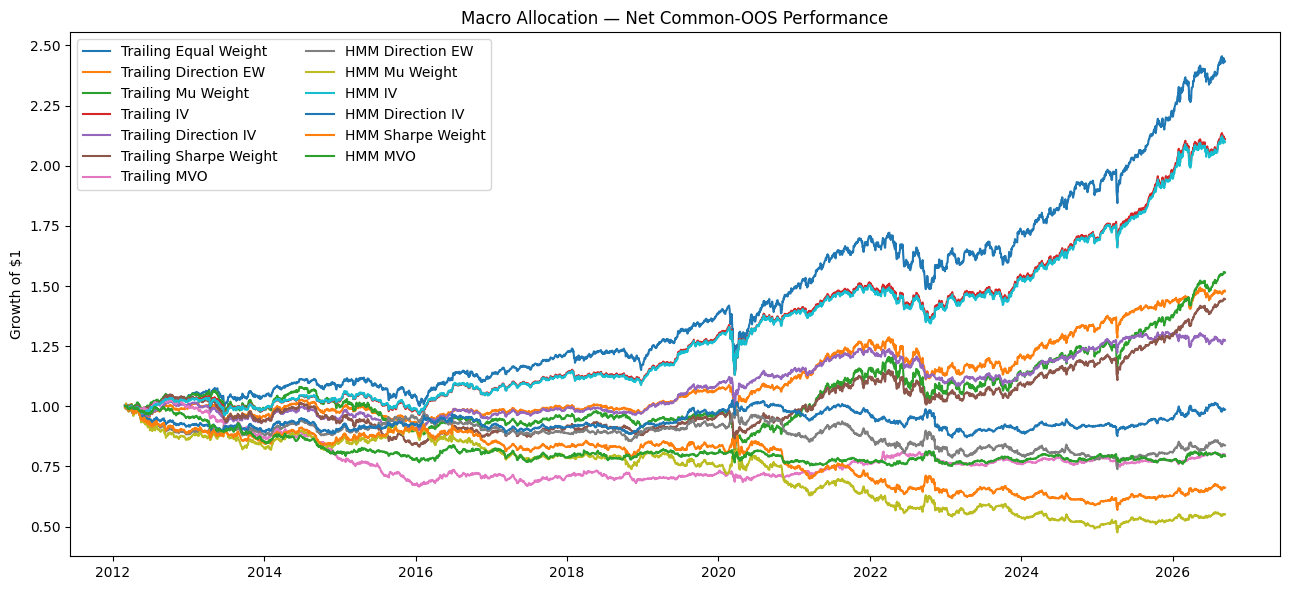

,Observed,Bootstrap Mean,2.5%,Median,97.5%,P(S > 0)
Trailing Equal Weight,0.8263,0.8373,0.3158,0.8313,1.3706,0.9990
Trailing Direction EW,0.4760,0.4783,-0.0131,0.4795,0.9808,0.9726
Trailing Mu Weight,0.4226,0.4267,-0.0674,0.4262,0.9401,0.9540
Trailing IV,0.8639,0.8727,0.3484,0.8669,1.4237,0.9998
Trailing Direction IV,0.3435,0.3450,-0.1619,0.3452,0.8527,0.9098
Trailing Sharpe Weight,0.4004,0.4048,-0.0814,0.4035,0.9114,0.9472
Trailing MVO,-0.2522,-0.2523,-0.7370,-0.2485,0.2125,0.1502
HMM Direction EW,-0.1597,-0.1592,-0.6275,-0.1616,0.3159,0.2482
HMM Mu Weight,-0.4054,-0.4085,-0.8753,-0.4054,0.0615,0.0466
HMM IV,0.8667,0.8746,0.3512,0.8704,1.4189,0.9996


In [17]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yfinance as yf
from scipy.stats import skew, multivariate_normal
from scipy.special import logsumexp
from sklearn.covariance import LedoitWolf
from hmmlearn.hmm import GaussianHMM

ASSETS=["SPY","EFA","IEF","LQD","GLD","DBC","UUP","VNQ"]
TRAIL=252*5
HMM_STATES=3
HMM_WINDOW=252*5
HMM_N_ITER=500
TC_BPS=5
N_BOOT=5000
BLOCK=20
SEED=42

px=yf.download(
    ASSETS,
    start="2006-01-01",
    auto_adjust=True,
    progress=False
)["Close"]

r=px.pct_change(fill_method=None).dropna()

def l1(w):
    w=np.asarray(w,float)
    d=np.abs(w).sum()
    return w/d if d>0 else np.zeros_like(w)

def lw(x):
    return LedoitWolf().fit(np.asarray(x)).covariance_

def dew(mu):
    return l1(np.sign(mu))

def muw(mu):
    return l1(mu)

def iv(sd):
    return l1(1/np.maximum(sd,1e-12))

def div(mu,sd):
    return l1(np.sign(mu)/np.maximum(sd,1e-12))

def sw(mu,sd):
    return l1(mu/np.maximum(sd,1e-12))

def mvo(mu,cov):
    return l1(np.linalg.pinv(cov)@mu)

def metrics(x):
    x=pd.Series(x).dropna()
    ar=x.mean()*252
    vol=x.std()*np.sqrt(252)
    sh=ar/vol if vol>0 else np.nan
    w=(1+x).cumprod()
    yrs=len(x)/252
    cagr=w.iloc[-1]**(1/yrs)-1
    dd=w/w.cummax()-1
    return pd.Series({
        "CAGR":cagr,
        "Arithmetic Return":ar,
        "Volatility":vol,
        "Sharpe":sh,
        "Skew":skew(x,bias=False),
        "Max Drawdown":dd.min()
    })

def sr(x):
    s=np.std(x,ddof=1)
    return np.mean(x)/s*np.sqrt(252) if s>0 else np.nan

def sb(T,L,rng):
    p=1/L
    z=np.empty(T,dtype=int)
    z[0]=rng.integers(T)
    for t in range(1,T):
        z[t]=rng.integers(T) if rng.random()<p else (z[t-1]+1)%T
    return z

def fit_hmm(hist):
    a=hist.values
    mean=a.mean(0)
    sd=a.std(0,ddof=1)
    sd=np.where(sd>0,sd,1)
    X=(a-mean)/sd

    model=GaussianHMM(
        n_components=HMM_STATES,
        covariance_type="full",
        n_iter=HMM_N_ITER,
        random_state=SEED
    ).fit(X)

    gamma=model.predict_proba(X)
    means=[]
    covs=[]
    gc=lw(a)

    for k in range(HMM_STATES):
        q=gamma[:,k]
        mu=np.average(a,axis=0,weights=q)
        xc=a-mu
        cov=(xc*q[:,None]).T@xc/q.sum()
        covs.append(.5*cov+.5*gc)
        means.append(mu)

    return {
        "model":model,
        "alpha":gamma[-1],
        "mean":mean,
        "sd":sd,
        "means":np.asarray(means),
        "covs":np.asarray(covs)
    }

def update_hmm(state,obs):
    model=state["model"]
    z=(obs-state["mean"])/state["sd"]
    prior=state["alpha"]@model.transmat_

    ll=np.asarray([
        multivariate_normal.logpdf(
            z,
            mean=model.means_[k],
            cov=model.covars_[k],
            allow_singular=True
        )
        for k in range(HMM_STATES)
    ])

    p=np.log(np.clip(prior,1e-300,None))+ll
    state["alpha"]=np.exp(p-logsumexp(p))

def hmm_fc(state,h=1):
    p=state["alpha"].copy()
    mus=[]
    secs=[]

    for _ in range(h):
        p=p@state["model"].transmat_
        mu=np.sum(p[:,None]*state["means"],axis=0)
        sec=sum(
            p[k]*(state["covs"][k]+np.outer(state["means"][k],state["means"][k]))
            for k in range(HMM_STATES)
        )
        mus.append(mu)
        secs.append(sec)

    mu=np.mean(mus,axis=0)
    cov=np.mean(secs,axis=0)-np.outer(mu,mu)
    cov=(cov+cov.T)/2

    e=np.linalg.eigvalsh(cov)
    if e.min()<1e-12:
        cov+=np.eye(len(mu))*(1e-12-e.min())

    return mu,cov

BASE=[
    "Equal Weight",
    "Direction EW",
    "Mu Weight",
    "IV",
    "Direction IV",
    "Sharpe Weight",
    "MVO"
]

TRAIL_NAMES=["Trailing "+x for x in BASE]
HMM_NAMES=["HMM "+x for x in BASE[1:]]
HMM21_NAMES=["HMM21 "+x for x in BASE[1:]]

STRATS=TRAIL_NAMES+HMM_NAMES

gross=pd.DataFrame(np.nan,index=r.index,columns=STRATS)
gross21=pd.DataFrame(np.nan,index=r.index,columns=HMM21_NAMES)

weights={s:{} for s in STRATS}
weights21={s:{} for s in HMM21_NAMES}

periods=r.index.to_period("M")
state=None
last_q=None

for month in sorted(periods.unique()):
    dates=r.index[periods==month]
    if len(dates)==0:
        continue

    pos=r.index.get_loc(dates[0])
    if pos==0:
        continue

    info=r.index[pos-1]
    hist=r.loc[:info].tail(TRAIL)
    R=r.loc[dates,ASSETS].values

    ew=np.ones(len(ASSETS))/len(ASSETS)
    weights["Trailing Equal Weight"][month]=ew
    gross.loc[dates,"Trailing Equal Weight"]=R@ew

    if len(hist)>=TRAIL:
        mu=hist.mean().values
        sd=hist.std().values
        cov=lw(hist.values)

        W=[
            dew(mu),
            muw(mu),
            iv(sd),
            div(mu,sd),
            sw(mu,sd),
            mvo(mu,cov)
        ]

        for s,w in zip(TRAIL_NAMES[1:],W):
            weights[s][month]=w
            gross.loc[dates,s]=R@w

    q=(month.year,month.quarter)

    if q!=last_q and len(hist)>=HMM_WINDOW:
        state=fit_hmm(hist.tail(HMM_WINDOW))
        last_q=q

    if state is not None:
        mu,cov=hmm_fc(state,1)
        sd=np.sqrt(np.diag(cov))

        mu21,cov21=hmm_fc(state,21)
        sd21=np.sqrt(np.diag(cov21))

        W=[
            dew(mu),
            muw(mu),
            iv(sd),
            div(mu,sd),
            sw(mu,sd),
            mvo(mu,cov)
        ]

        W21=[
            dew(mu21),
            muw(mu21),
            iv(sd21),
            div(mu21,sd21),
            sw(mu21,sd21),
            mvo(mu21,cov21)
        ]

        for s,w in zip(HMM_NAMES,W):
            weights[s][month]=w
            gross.loc[dates,s]=R@w

        for s,w in zip(HMM21_NAMES,W21):
            weights21[s][month]=w
            gross21.loc[dates,s]=R@w

        for obs in R:
            update_hmm(state,obs)

def apply_cost(gross,weights):
    net=gross.copy()
    turn=pd.DataFrame(0.,index=gross.index,columns=gross.columns)

    for s in gross.columns:
        prev=np.zeros(len(ASSETS))

        for month in sorted(gross.index.to_period("M").unique()):
            dates=gross.index[gross.index.to_period("M")==month]

            if month not in weights[s]:
                continue

            cur=np.asarray(weights[s][month])
            t=np.abs(cur-prev).sum()

            turn.loc[dates[0],s]=t
            net.loc[dates[0],s]-=t*TC_BPS/1e4
            prev=cur

    return net,turn

net,turn=apply_cost(gross,weights)
net21,turn21=apply_cost(gross21,weights21)

common=gross[STRATS].dropna().index
G=gross.loc[common]
N=net.loc[common]
T=turn.loc[common]

res=pd.DataFrame({s:metrics(N[s]) for s in STRATS}).T
gross_res=pd.DataFrame({s:metrics(G[s]) for s in STRATS}).T

years=len(common)/252
months=common.to_period("M").nunique()

cost_summary=pd.DataFrame({
    "Gross Sharpe":gross_res["Sharpe"],
    "Net Sharpe":res["Sharpe"],
    "Avg Monthly Turnover":T.sum()/months,
    "Annualized Turnover":T.sum()/years
})

display(res.round(4))
display(cost_summary.round(4))

rob_idx=gross21.dropna().index.intersection(common)

rob=pd.DataFrame({
    s:metrics(net21.loc[rob_idx,s])
    for s in HMM21_NAMES
}).T

display(rob.round(4))

wealth=(1+N).cumprod()

plt.figure(figsize=(13,6))
for s in STRATS:
    plt.plot(wealth.index,wealth[s],label=s)
plt.ylabel("Growth of $1")
plt.title("Macro Allocation — Net Common-OOS Performance")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

rng=np.random.default_rng(SEED)
A=N.values
boot=np.empty((N_BOOT,len(STRATS)))

for b in range(N_BOOT):
    ii=sb(len(A),BLOCK,rng)
    z=A[ii]
    for j in range(len(STRATS)):
        boot[b,j]=sr(z[:,j])

boot=pd.DataFrame(boot,columns=STRATS)

bs=pd.DataFrame({
    "Observed":res["Sharpe"],
    "Bootstrap Mean":boot.mean(),
    "2.5%":boot.quantile(.025),
    "Median":boot.median(),
    "97.5%":boot.quantile(.975),
    "P(S > 0)":(boot>0).mean()
})

display(bs.round(4))

# Sector Rotation

,CAGR,Arithmetic Return,Volatility,Sharpe,Skew,Max Drawdown
Trailing Equal Weight,0.1078,0.1185,0.1791,0.6616,-0.2805,-0.5253
Trailing Direction EW,0.0970,0.1036,0.1482,0.6992,-0.1315,-0.4248
Trailing Mu Weight,0.0934,0.1032,0.1669,0.6185,-0.1370,-0.4523
Trailing IV,0.1076,0.1166,0.1695,0.6877,-0.2801,-0.4981
Trailing Direction IV,0.0987,0.1050,0.1467,0.7156,-0.1448,-0.4033
Trailing Sharpe Weight,0.0958,0.1046,0.1614,0.6477,-0.1490,-0.4295
Trailing MVO,0.0239,0.0258,0.0652,0.3950,-0.3272,-0.2152
HMM Direction EW,0.0355,0.0474,0.1579,0.3003,-0.0698,-0.5509
HMM Mu Weight,0.0373,0.0516,0.1733,0.2980,-0.1412,-0.5773
HMM IV,0.1076,0.1166,0.1692,0.6888,-0.2745,-0.4908


,Gross Sharpe,Net Sharpe,Avg Monthly Turnover,Annualized Turnover
Trailing Equal Weight,0.6616,0.6616,0.0000,0.0000
Trailing Direction EW,0.7003,0.6992,0.0281,0.3385
Trailing Mu Weight,0.6217,0.6185,0.0905,1.0906
Trailing IV,0.6879,0.6877,0.0081,0.0975
Trailing Direction IV,0.7168,0.7156,0.0305,0.3674
Trailing Sharpe Weight,0.6510,0.6477,0.0884,1.0656
Trailing MVO,0.4165,0.3950,0.2339,2.8202
HMM Direction EW,0.3155,0.3003,0.3960,4.7738
HMM Mu Weight,0.3185,0.2980,0.5879,7.0864
HMM IV,0.6895,0.6888,0.0187,0.2249


,CAGR,Arithmetic Return,Volatility,Sharpe,Skew,Max Drawdown
HMM21 Direction EW,0.1011,0.1091,0.1596,0.6835,-0.5480,-0.3691
HMM21 Mu Weight,0.1063,0.1157,0.1708,0.6773,-0.4762,-0.3555
HMM21 IV,0.1077,0.1166,0.1693,0.6888,-0.2754,-0.4937
HMM21 Direction IV,0.1037,0.1101,0.1512,0.7285,-0.5429,-0.3583
HMM21 Sharpe Weight,0.1070,0.1150,0.1625,0.7074,-0.4813,-0.3401
HMM21 MVO,0.0271,0.0289,0.0662,0.4367,-0.5099,-0.2572


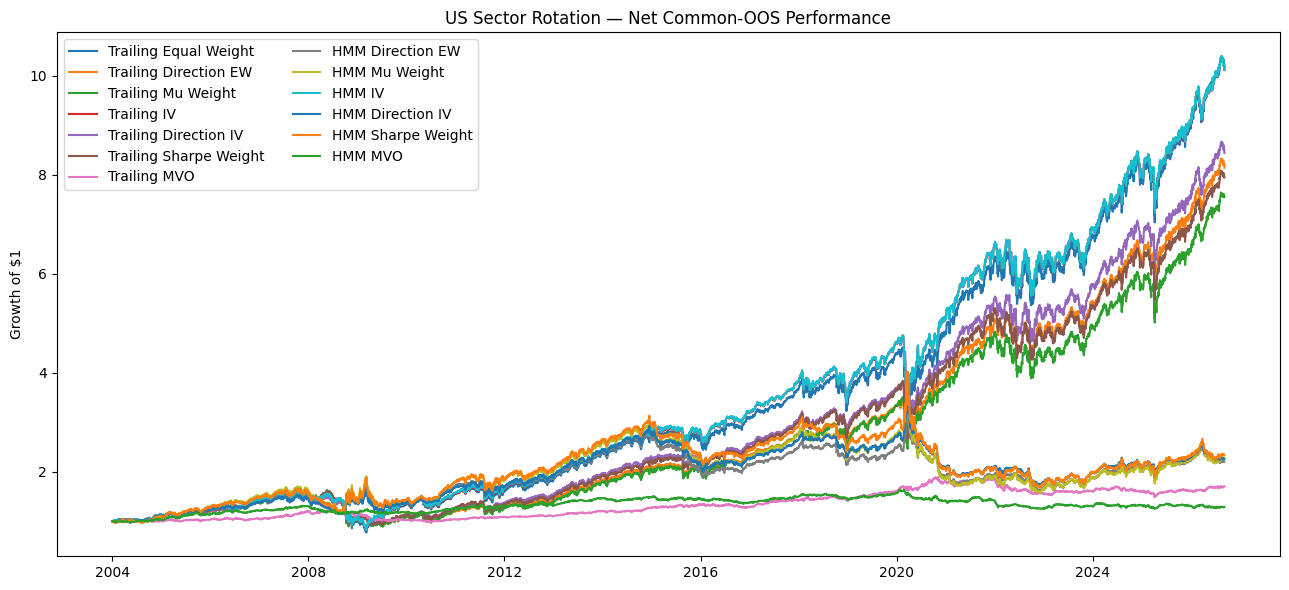

,Observed,Bootstrap Mean,2.5%,Median,97.5%,P(S > 0)
Trailing Equal Weight,0.6616,0.6768,0.2903,0.6728,1.0819,0.9996
Trailing Direction EW,0.6992,0.7137,0.3266,0.7082,1.1255,1.0000
Trailing Mu Weight,0.6185,0.6328,0.2523,0.6245,1.0299,0.9998
Trailing IV,0.6877,0.7032,0.3153,0.7020,1.1114,0.9998
Trailing Direction IV,0.7156,0.7299,0.3437,0.7249,1.1380,1.0000
Trailing Sharpe Weight,0.6477,0.6619,0.2792,0.6559,1.0610,0.9998
Trailing MVO,0.3950,0.3983,0.0376,0.3915,0.7810,0.9854
HMM Direction EW,0.3003,0.3008,-0.0858,0.3041,0.6616,0.9432
HMM Mu Weight,0.2980,0.2977,-0.0753,0.2992,0.6523,0.9442
HMM IV,0.6888,0.7043,0.3189,0.7034,1.1124,0.9998


In [18]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yfinance as yf
from scipy.stats import skew, multivariate_normal
from scipy.special import logsumexp
from sklearn.covariance import LedoitWolf
from hmmlearn.hmm import GaussianHMM

ASSETS=["XLB","XLE","XLF","XLI","XLK","XLP","XLU","XLV","XLY"]
TRAIL=252*5
HMM_STATES=3
HMM_WINDOW=252*5
HMM_N_ITER=500
TC_BPS=5
N_BOOT=5000
BLOCK=20
SEED=42

px=yf.download(
    ASSETS,start="1998-12-22",
    auto_adjust=True,progress=False
)["Close"]

r=px.pct_change(fill_method=None).dropna()

def l1(w):
    w=np.asarray(w,float)
    d=np.abs(w).sum()
    return w/d if d else np.zeros_like(w)

def lw(x):
    return LedoitWolf().fit(np.asarray(x)).covariance_

def dew(mu): return l1(np.sign(mu))
def muw(mu): return l1(mu)
def iv(sd): return l1(1/np.maximum(sd,1e-12))
def div(mu,sd): return l1(np.sign(mu)/np.maximum(sd,1e-12))
def sw(mu,sd): return l1(mu/np.maximum(sd,1e-12))
def mvo(mu,cov): return l1(np.linalg.pinv(cov)@mu)

def metrics(x):
    x=pd.Series(x).dropna()
    ar=x.mean()*252
    vol=x.std()*np.sqrt(252)
    sh=ar/vol if vol else np.nan
    wealth=(1+x).cumprod()
    yrs=len(x)/252
    dd=wealth/wealth.cummax()-1
    return pd.Series({
        "CAGR":wealth.iloc[-1]**(1/yrs)-1,
        "Arithmetic Return":ar,
        "Volatility":vol,
        "Sharpe":sh,
        "Skew":skew(x,bias=False),
        "Max Drawdown":dd.min()
    })

def sr(x):
    s=np.std(x,ddof=1)
    return np.mean(x)/s*np.sqrt(252) if s else np.nan

def sb(T,L,rng):
    p=1/L
    z=np.empty(T,dtype=int)
    z[0]=rng.integers(T)
    for t in range(1,T):
        z[t]=rng.integers(T) if rng.random()<p else (z[t-1]+1)%T
    return z

def fit_hmm(hist):
    a=hist.values
    mean=a.mean(0)
    sd=a.std(0,ddof=1)
    sd=np.where(sd>0,sd,1)
    X=(a-mean)/sd

    model=GaussianHMM(
        n_components=HMM_STATES,
        covariance_type="full",
        n_iter=HMM_N_ITER,
        random_state=SEED
    ).fit(X)

    gamma=model.predict_proba(X)
    means=[]
    covs=[]
    global_cov=lw(a)

    for k in range(HMM_STATES):
        q=gamma[:,k]
        mu=np.average(a,axis=0,weights=q)
        xc=a-mu
        wcov=(xc*q[:,None]).T@xc/q.sum()
        means.append(mu)
        covs.append(.5*wcov+.5*global_cov)

    return {
        "model":model,
        "alpha":gamma[-1],
        "mean":mean,
        "sd":sd,
        "means":np.asarray(means),
        "covs":np.asarray(covs)
    }

def update_hmm(state,obs):
    model=state["model"]
    z=(obs-state["mean"])/state["sd"]
    prior=state["alpha"]@model.transmat_

    ll=np.array([
        multivariate_normal.logpdf(
            z,mean=model.means_[k],
            cov=model.covars_[k],
            allow_singular=True
        )
        for k in range(HMM_STATES)
    ])

    q=np.log(np.clip(prior,1e-300,None))+ll
    state["alpha"]=np.exp(q-logsumexp(q))

def hmm_fc(state,h=1):
    p=state["alpha"].copy()
    mus=[]
    seconds=[]

    for _ in range(h):
        p=p@state["model"].transmat_
        mu=np.sum(p[:,None]*state["means"],axis=0)
        sec=sum(
            p[k]*(state["covs"][k]+np.outer(state["means"][k],state["means"][k]))
            for k in range(HMM_STATES)
        )
        mus.append(mu)
        seconds.append(sec)

    mu=np.mean(mus,axis=0)
    cov=np.mean(seconds,axis=0)-np.outer(mu,mu)
    cov=(cov+cov.T)/2

    e=np.linalg.eigvalsh(cov)
    if e.min()<1e-12:
        cov+=np.eye(len(mu))*(1e-12-e.min())

    return mu,cov

BASE=[
    "Equal Weight",
    "Direction EW",
    "Mu Weight",
    "IV",
    "Direction IV",
    "Sharpe Weight",
    "MVO"
]

TRAIL_NAMES=["Trailing "+s for s in BASE]
HMM_NAMES=["HMM "+s for s in BASE[1:]]
HMM21_NAMES=["HMM21 "+s for s in BASE[1:]]
STRATS=TRAIL_NAMES+HMM_NAMES

gross=pd.DataFrame(np.nan,index=r.index,columns=STRATS)
gross21=pd.DataFrame(np.nan,index=r.index,columns=HMM21_NAMES)

weights={s:{} for s in STRATS}
weights21={s:{} for s in HMM21_NAMES}

periods=r.index.to_period("M")
state=None
last_q=None

for month in sorted(periods.unique()):
    dates=r.index[periods==month]
    if not len(dates): continue

    p=r.index.get_loc(dates[0])
    if p==0: continue

    info=r.index[p-1]
    hist=r.loc[:info].tail(TRAIL)
    R=r.loc[dates,ASSETS].values

    w=np.ones(len(ASSETS))/len(ASSETS)
    weights["Trailing Equal Weight"][month]=w
    gross.loc[dates,"Trailing Equal Weight"]=R@w

    if len(hist)>=TRAIL:
        mu=hist.mean().values
        sd=hist.std().values
        cov=lw(hist.values)

        W=[
            dew(mu),
            muw(mu),
            iv(sd),
            div(mu,sd),
            sw(mu,sd),
            mvo(mu,cov)
        ]

        for s,w in zip(TRAIL_NAMES[1:],W):
            weights[s][month]=w
            gross.loc[dates,s]=R@w

    q=(month.year,month.quarter)

    if q!=last_q and len(hist)>=HMM_WINDOW:
        state=fit_hmm(hist.tail(HMM_WINDOW))
        last_q=q

    if state is not None:
        mu,cov=hmm_fc(state,1)
        sd=np.sqrt(np.diag(cov))

        mu21,cov21=hmm_fc(state,21)
        sd21=np.sqrt(np.diag(cov21))

        W=[
            dew(mu),muw(mu),iv(sd),
            div(mu,sd),sw(mu,sd),mvo(mu,cov)
        ]

        W21=[
            dew(mu21),muw(mu21),iv(sd21),
            div(mu21,sd21),sw(mu21,sd21),mvo(mu21,cov21)
        ]

        for s,w in zip(HMM_NAMES,W):
            weights[s][month]=w
            gross.loc[dates,s]=R@w

        for s,w in zip(HMM21_NAMES,W21):
            weights21[s][month]=w
            gross21.loc[dates,s]=R@w

        for obs in R:
            update_hmm(state,obs)

def apply_cost(gross,weights):
    net=gross.copy()
    turn=pd.DataFrame(0.,index=gross.index,columns=gross.columns)

    for s in gross.columns:
        prev=np.zeros(len(ASSETS))

        for month in sorted(gross.index.to_period("M").unique()):
            dates=gross.index[gross.index.to_period("M")==month]

            if month not in weights[s]:
                continue

            cur=np.asarray(weights[s][month])
            t=np.abs(cur-prev).sum()

            turn.loc[dates[0],s]=t
            net.loc[dates[0],s]-=t*TC_BPS/1e4
            prev=cur

    return net,turn

net,turn=apply_cost(gross,weights)
net21,turn21=apply_cost(gross21,weights21)

common=gross[STRATS].dropna().index
G=gross.loc[common]
N=net.loc[common]
T=turn.loc[common]

res=pd.DataFrame({s:metrics(N[s]) for s in STRATS}).T
gres=pd.DataFrame({s:metrics(G[s]) for s in STRATS}).T

years=len(common)/252
months=common.to_period("M").nunique()

cost_summary=pd.DataFrame({
    "Gross Sharpe":gres["Sharpe"],
    "Net Sharpe":res["Sharpe"],
    "Avg Monthly Turnover":T.sum()/months,
    "Annualized Turnover":T.sum()/years
})

display(res.round(4))
display(cost_summary.round(4))

rob_idx=gross21.dropna().index.intersection(common)

rob=pd.DataFrame({
    s:metrics(net21.loc[rob_idx,s])
    for s in HMM21_NAMES
}).T

display(rob.round(4))

wealth=(1+N).cumprod()

plt.figure(figsize=(13,6))
for s in STRATS:
    plt.plot(wealth.index,wealth[s],label=s)
plt.ylabel("Growth of $1")
plt.title("US Sector Rotation — Net Common-OOS Performance")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

rng=np.random.default_rng(SEED)
A=N.values
boot=np.empty((N_BOOT,len(STRATS)))

for b in range(N_BOOT):
    ii=sb(len(A),BLOCK,rng)
    z=A[ii]

    for j in range(len(STRATS)):
        boot[b,j]=sr(z[:,j])

boot=pd.DataFrame(boot,columns=STRATS)

bs=pd.DataFrame({
    "Observed":res["Sharpe"],
    "Bootstrap Mean":boot.mean(),
    "2.5%":boot.quantile(.025),
    "Median":boot.median(),
    "97.5%":boot.quantile(.975),
    "P(S > 0)":(boot>0).mean()
})

display(bs.round(4))

# FX Rotation

,CAGR,Arithmetic Return,Volatility,Sharpe,Skew,Max Drawdown
Trailing Equal Weight,-0.0179,-0.0158,0.0674,-0.2337,0.1889,-0.3447
Trailing Direction EW,-0.0128,-0.0116,0.0517,-0.2242,0.0150,-0.2099
Trailing Mu Weight,-0.0126,-0.0109,0.0600,-0.1813,-0.0679,-0.2185
Trailing IV,-0.0176,-0.0156,0.0658,-0.2367,0.1663,-0.3422
Trailing Direction IV,-0.0095,-0.0083,0.0495,-0.1683,-0.0105,-0.1656
Trailing Sharpe Weight,-0.0101,-0.0085,0.0583,-0.1457,-0.1106,-0.1929
Trailing MVO,-0.0033,-0.0028,0.0307,-0.0927,0.8386,-0.1521
HMM Direction EW,-0.0218,-0.0207,0.0521,-0.3974,-0.3698,-0.3180
HMM Mu Weight,-0.0270,-0.0253,0.0636,-0.3979,-0.2174,-0.3871
HMM IV,-0.0178,-0.0158,0.0658,-0.2393,0.1734,-0.3438


,Gross Sharpe,Net Sharpe,Avg Monthly Turnover,Annualized Turnover
Trailing Equal Weight,-0.2337,-0.2337,0.0000,0.0000
Trailing Direction EW,-0.2068,-0.2242,0.1537,1.7932
Trailing Mu Weight,-0.1597,-0.1813,0.2223,2.5942
Trailing IV,-0.2357,-0.2367,0.0114,0.1328
Trailing Direction IV,-0.1500,-0.1683,0.1553,1.8117
Trailing Sharpe Weight,-0.1237,-0.1457,0.2195,2.5611
Trailing MVO,-0.0503,-0.0927,0.2233,2.6055
HMM Direction EW,-0.3453,-0.3974,0.4672,5.4518
HMM Mu Weight,-0.3377,-0.3979,0.6575,7.6723
HMM IV,-0.2376,-0.2393,0.0199,0.2326


,CAGR,Arithmetic Return,Volatility,Sharpe,Skew,Max Drawdown
HMM21 Direction EW,-0.0136,-0.0125,0.0502,-0.2485,-0.2325,-0.2241
HMM21 Mu Weight,-0.0210,-0.0194,0.0601,-0.3223,-0.1816,-0.3364
HMM21 IV,-0.0176,-0.0156,0.0659,-0.2369,0.1696,-0.3425
HMM21 Direction IV,-0.0113,-0.0102,0.0481,-0.2125,-0.2048,-0.1944
HMM21 Sharpe Weight,-0.0187,-0.0172,0.0584,-0.2944,-0.2118,-0.3143
HMM21 MVO,-0.0052,-0.0048,0.0298,-0.1617,0.1451,-0.1855


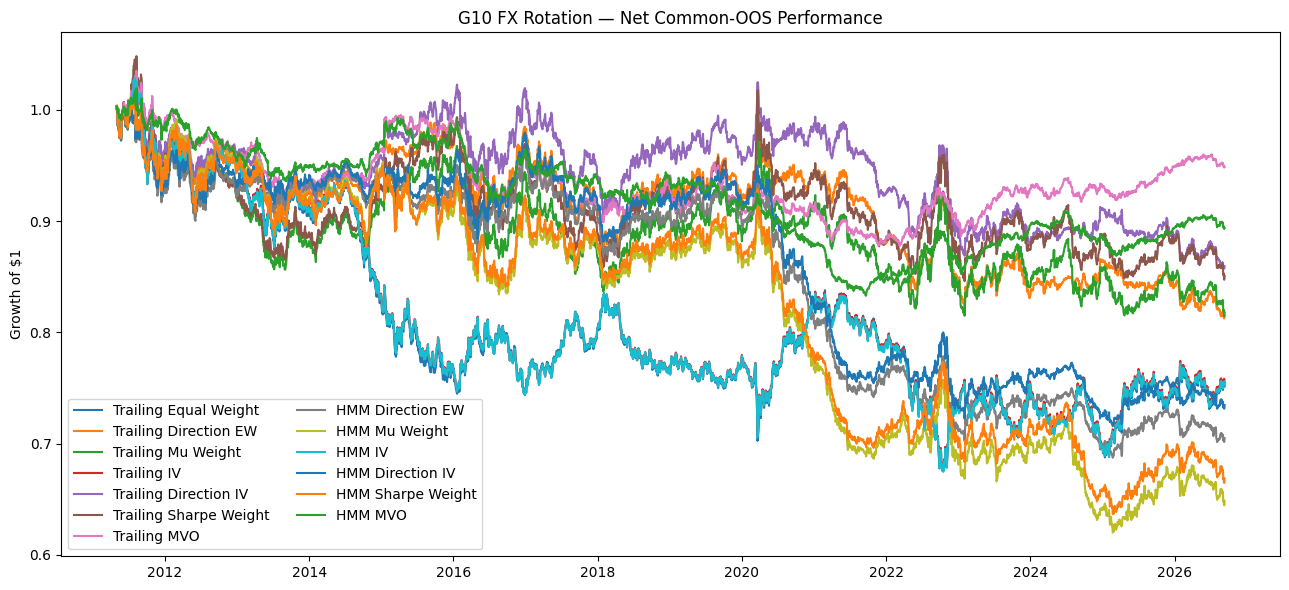

,Observed,Bootstrap Mean,2.5%,Median,97.5%,P(S > 0)
Trailing Equal Weight,-0.2337,-0.2376,-0.6736,-0.2374,0.2085,0.1490
Trailing Direction EW,-0.2242,-0.2229,-0.6780,-0.2221,0.2374,0.1684
Trailing Mu Weight,-0.1813,-0.1791,-0.6555,-0.1820,0.3086,0.2180
Trailing IV,-0.2367,-0.2403,-0.6753,-0.2404,0.2100,0.1504
Trailing Direction IV,-0.1683,-0.1666,-0.6254,-0.1662,0.3020,0.2370
Trailing Sharpe Weight,-0.1457,-0.1430,-0.6238,-0.1449,0.3460,0.2714
Trailing MVO,-0.0927,-0.0940,-0.5795,-0.0930,0.3894,0.3462
HMM Direction EW,-0.3974,-0.3977,-0.8360,-0.3997,0.0536,0.0410
HMM Mu Weight,-0.3979,-0.3965,-0.8548,-0.3985,0.0670,0.0464
HMM IV,-0.2393,-0.2429,-0.6797,-0.2424,0.2079,0.1486


In [19]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yfinance as yf
from scipy.stats import skew, multivariate_normal
from scipy.special import logsumexp
from sklearn.covariance import LedoitWolf
from hmmlearn.hmm import GaussianHMM

TICKERS=["EURUSD=X","GBPUSD=X","AUDUSD=X","NZDUSD=X","JPY=X","CAD=X","CHF=X"]
ASSETS=["EUR","GBP","AUD","NZD","JPY","CAD","CHF"]

TRAIL=252*5
HMM_STATES=3
HMM_WINDOW=252*5
HMM_N_ITER=500
TC_BPS=5
N_BOOT=5000
BLOCK=20
SEED=42

px=yf.download(
    TICKERS,start="2000-01-01",
    auto_adjust=True,progress=False
)["Close"]

q=pd.DataFrame(index=px.index)
q["EUR"]=px["EURUSD=X"]
q["GBP"]=px["GBPUSD=X"]
q["AUD"]=px["AUDUSD=X"]
q["NZD"]=px["NZDUSD=X"]
q["JPY"]=1/px["JPY=X"]
q["CAD"]=1/px["CAD=X"]
q["CHF"]=1/px["CHF=X"]

r=q.pct_change(fill_method=None).dropna()

def l1(w):
    w=np.asarray(w,float)
    d=np.abs(w).sum()
    return w/d if d else np.zeros_like(w)

def lw(x):
    return LedoitWolf().fit(np.asarray(x)).covariance_

def dew(mu): return l1(np.sign(mu))
def muw(mu): return l1(mu)
def iv(sd): return l1(1/np.maximum(sd,1e-12))
def div(mu,sd): return l1(np.sign(mu)/np.maximum(sd,1e-12))
def sw(mu,sd): return l1(mu/np.maximum(sd,1e-12))
def mvo(mu,cov): return l1(np.linalg.pinv(cov)@mu)

def metrics(x):
    x=pd.Series(x).dropna()
    ar=x.mean()*252
    vol=x.std()*np.sqrt(252)
    sh=ar/vol if vol else np.nan
    wealth=(1+x).cumprod()
    yrs=len(x)/252
    dd=wealth/wealth.cummax()-1
    return pd.Series({
        "CAGR":wealth.iloc[-1]**(1/yrs)-1,
        "Arithmetic Return":ar,
        "Volatility":vol,
        "Sharpe":sh,
        "Skew":skew(x,bias=False),
        "Max Drawdown":dd.min()
    })

def sr(x):
    s=np.std(x,ddof=1)
    return np.mean(x)/s*np.sqrt(252) if s else np.nan

def sb(T,L,rng):
    p=1/L
    z=np.empty(T,dtype=int)
    z[0]=rng.integers(T)
    for t in range(1,T):
        z[t]=rng.integers(T) if rng.random()<p else (z[t-1]+1)%T
    return z

def fit_hmm(hist):
    a=hist.values
    mean=a.mean(0)
    sd=a.std(0,ddof=1)
    sd=np.where(sd>0,sd,1)
    X=(a-mean)/sd

    model=GaussianHMM(
        n_components=HMM_STATES,
        covariance_type="full",
        n_iter=HMM_N_ITER,
        random_state=SEED
    ).fit(X)

    gamma=model.predict_proba(X)
    gc=lw(a)
    means=[]
    covs=[]

    for k in range(HMM_STATES):
        p=gamma[:,k]
        mu=np.average(a,axis=0,weights=p)
        xc=a-mu
        wcov=(xc*p[:,None]).T@xc/p.sum()
        means.append(mu)
        covs.append(.5*wcov+.5*gc)

    return {
        "model":model,
        "alpha":gamma[-1],
        "mean":mean,
        "sd":sd,
        "means":np.asarray(means),
        "covs":np.asarray(covs)
    }

def update_hmm(state,obs):
    model=state["model"]
    z=(obs-state["mean"])/state["sd"]
    prior=state["alpha"]@model.transmat_

    ll=np.array([
        multivariate_normal.logpdf(
            z,
            mean=model.means_[k],
            cov=model.covars_[k],
            allow_singular=True
        )
        for k in range(HMM_STATES)
    ])

    p=np.log(np.clip(prior,1e-300,None))+ll
    state["alpha"]=np.exp(p-logsumexp(p))

def hmm_fc(state,h=1):
    p=state["alpha"].copy()
    mus=[]
    seconds=[]

    for _ in range(h):
        p=p@state["model"].transmat_
        mu=np.sum(p[:,None]*state["means"],axis=0)
        sec=sum(
            p[k]*(state["covs"][k]+np.outer(state["means"][k],state["means"][k]))
            for k in range(HMM_STATES)
        )
        mus.append(mu)
        seconds.append(sec)

    mu=np.mean(mus,axis=0)
    cov=np.mean(seconds,axis=0)-np.outer(mu,mu)
    cov=(cov+cov.T)/2

    e=np.linalg.eigvalsh(cov)
    if e.min()<1e-12:
        cov+=np.eye(len(mu))*(1e-12-e.min())

    return mu,cov

BASE=[
    "Equal Weight",
    "Direction EW",
    "Mu Weight",
    "IV",
    "Direction IV",
    "Sharpe Weight",
    "MVO"
]

TRAIL_NAMES=["Trailing "+s for s in BASE]
HMM_NAMES=["HMM "+s for s in BASE[1:]]
HMM21_NAMES=["HMM21 "+s for s in BASE[1:]]
STRATS=TRAIL_NAMES+HMM_NAMES

gross=pd.DataFrame(np.nan,index=r.index,columns=STRATS)
gross21=pd.DataFrame(np.nan,index=r.index,columns=HMM21_NAMES)

weights={s:{} for s in STRATS}
weights21={s:{} for s in HMM21_NAMES}

periods=r.index.to_period("M")
state=None
last_q=None

for month in sorted(periods.unique()):
    dates=r.index[periods==month]
    if not len(dates):
        continue

    pos=r.index.get_loc(dates[0])
    if pos==0:
        continue

    info=r.index[pos-1]
    hist=r.loc[:info].tail(TRAIL)
    R=r.loc[dates,ASSETS].values

    w=np.ones(len(ASSETS))/len(ASSETS)
    weights["Trailing Equal Weight"][month]=w
    gross.loc[dates,"Trailing Equal Weight"]=R@w

    if len(hist)>=TRAIL:
        mu=hist.mean().values
        sd=hist.std().values
        cov=lw(hist.values)

        W=[
            dew(mu),
            muw(mu),
            iv(sd),
            div(mu,sd),
            sw(mu,sd),
            mvo(mu,cov)
        ]

        for s,w in zip(TRAIL_NAMES[1:],W):
            weights[s][month]=w
            gross.loc[dates,s]=R@w

    qtr=(month.year,month.quarter)

    if qtr!=last_q and len(hist)>=HMM_WINDOW:
        state=fit_hmm(hist.tail(HMM_WINDOW))
        last_q=qtr

    if state is not None:
        mu,cov=hmm_fc(state,1)
        sd=np.sqrt(np.diag(cov))

        mu21,cov21=hmm_fc(state,21)
        sd21=np.sqrt(np.diag(cov21))

        W=[
            dew(mu),muw(mu),iv(sd),
            div(mu,sd),sw(mu,sd),mvo(mu,cov)
        ]

        W21=[
            dew(mu21),muw(mu21),iv(sd21),
            div(mu21,sd21),sw(mu21,sd21),mvo(mu21,cov21)
        ]

        for s,w in zip(HMM_NAMES,W):
            weights[s][month]=w
            gross.loc[dates,s]=R@w

        for s,w in zip(HMM21_NAMES,W21):
            weights21[s][month]=w
            gross21.loc[dates,s]=R@w

        for obs in R:
            update_hmm(state,obs)

def apply_cost(gross,weights):
    net=gross.copy()
    turn=pd.DataFrame(0.,index=gross.index,columns=gross.columns)

    for s in gross.columns:
        prev=np.zeros(len(ASSETS))

        for month in sorted(gross.index.to_period("M").unique()):
            dates=gross.index[gross.index.to_period("M")==month]

            if month not in weights[s]:
                continue

            cur=np.asarray(weights[s][month])
            t=np.abs(cur-prev).sum()

            turn.loc[dates[0],s]=t
            net.loc[dates[0],s]-=t*TC_BPS/1e4
            prev=cur

    return net,turn

net,turn=apply_cost(gross,weights)
net21,turn21=apply_cost(gross21,weights21)

common=gross[STRATS].dropna().index
G=gross.loc[common]
N=net.loc[common]
T=turn.loc[common]

res=pd.DataFrame({s:metrics(N[s]) for s in STRATS}).T
gres=pd.DataFrame({s:metrics(G[s]) for s in STRATS}).T

years=len(common)/252
months=common.to_period("M").nunique()

cost_summary=pd.DataFrame({
    "Gross Sharpe":gres["Sharpe"],
    "Net Sharpe":res["Sharpe"],
    "Avg Monthly Turnover":T.sum()/months,
    "Annualized Turnover":T.sum()/years
})

display(res.round(4))
display(cost_summary.round(4))

rob_idx=gross21.dropna().index.intersection(common)

rob=pd.DataFrame({
    s:metrics(net21.loc[rob_idx,s])
    for s in HMM21_NAMES
}).T

display(rob.round(4))

wealth=(1+N).cumprod()

plt.figure(figsize=(13,6))
for s in STRATS:
    plt.plot(wealth.index,wealth[s],label=s)
plt.ylabel("Growth of $1")
plt.title("G10 FX Rotation — Net Common-OOS Performance")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

rng=np.random.default_rng(SEED)
A=N.values
boot=np.empty((N_BOOT,len(STRATS)))

for b in range(N_BOOT):
    ii=sb(len(A),BLOCK,rng)
    z=A[ii]

    for j in range(len(STRATS)):
        boot[b,j]=sr(z[:,j])

boot=pd.DataFrame(boot,columns=STRATS)

bs=pd.DataFrame({
    "Observed":res["Sharpe"],
    "Bootstrap Mean":boot.mean(),
    "2.5%":boot.quantile(.025),
    "Median":boot.median(),
    "97.5%":boot.quantile(.975),
    "P(S > 0)":(boot>0).mean()
})

display(bs.round(4))

# Commodities Rotation

,CAGR,Arithmetic Return,Volatility,Sharpe,Skew,Max Drawdown
Trailing Equal Weight,-0.0179,-0.0157,0.0674,-0.2336,0.1889,-0.3447
Trailing Direction EW,-0.0128,-0.0116,0.0517,-0.2243,0.0150,-0.2099
Trailing Mu Weight,-0.0126,-0.0109,0.0600,-0.1814,-0.0679,-0.2185
Trailing IV,-0.0176,-0.0156,0.0658,-0.2366,0.1663,-0.3422
Trailing Direction IV,-0.0095,-0.0083,0.0495,-0.1684,-0.0105,-0.1656
Trailing Sharpe Weight,-0.0102,-0.0085,0.0583,-0.1458,-0.1106,-0.1929
Trailing MVO,-0.0033,-0.0029,0.0307,-0.0927,0.8387,-0.1521
HMM Direction EW,-0.0218,-0.0207,0.0521,-0.3976,-0.3699,-0.3180
HMM Mu Weight,-0.0270,-0.0253,0.0636,-0.3981,-0.2174,-0.3871
HMM IV,-0.0178,-0.0157,0.0658,-0.2392,0.1734,-0.3438


,Gross Sharpe,Net Sharpe,Avg Monthly Turnover,Annualized Turnover
Trailing Equal Weight,-0.2336,-0.2336,0.0000,0.0000
Trailing Direction EW,-0.2069,-0.2243,0.1537,1.7932
Trailing Mu Weight,-0.1598,-0.1814,0.2223,2.5942
Trailing IV,-0.2356,-0.2366,0.0114,0.1328
Trailing Direction IV,-0.1501,-0.1684,0.1553,1.8117
Trailing Sharpe Weight,-0.1239,-0.1458,0.2195,2.5611
Trailing MVO,-0.0504,-0.0927,0.2233,2.6055
HMM Direction EW,-0.3455,-0.3976,0.4672,5.4518
HMM Mu Weight,-0.3379,-0.3981,0.6575,7.6723
HMM IV,-0.2374,-0.2392,0.0199,0.2326


,CAGR,Arithmetic Return,Volatility,Sharpe,Skew,Max Drawdown
HMM21 Direction EW,-0.0137,-0.0125,0.0502,-0.2486,-0.2325,-0.2241
HMM21 Mu Weight,-0.0210,-0.0194,0.0601,-0.3225,-0.1817,-0.3364
HMM21 IV,-0.0176,-0.0156,0.0659,-0.2368,0.1696,-0.3425
HMM21 Direction IV,-0.0113,-0.0102,0.0481,-0.2126,-0.2048,-0.1944
HMM21 Sharpe Weight,-0.0187,-0.0172,0.0584,-0.2946,-0.2118,-0.3143
HMM21 MVO,-0.0052,-0.0048,0.0298,-0.1618,0.1451,-0.1855


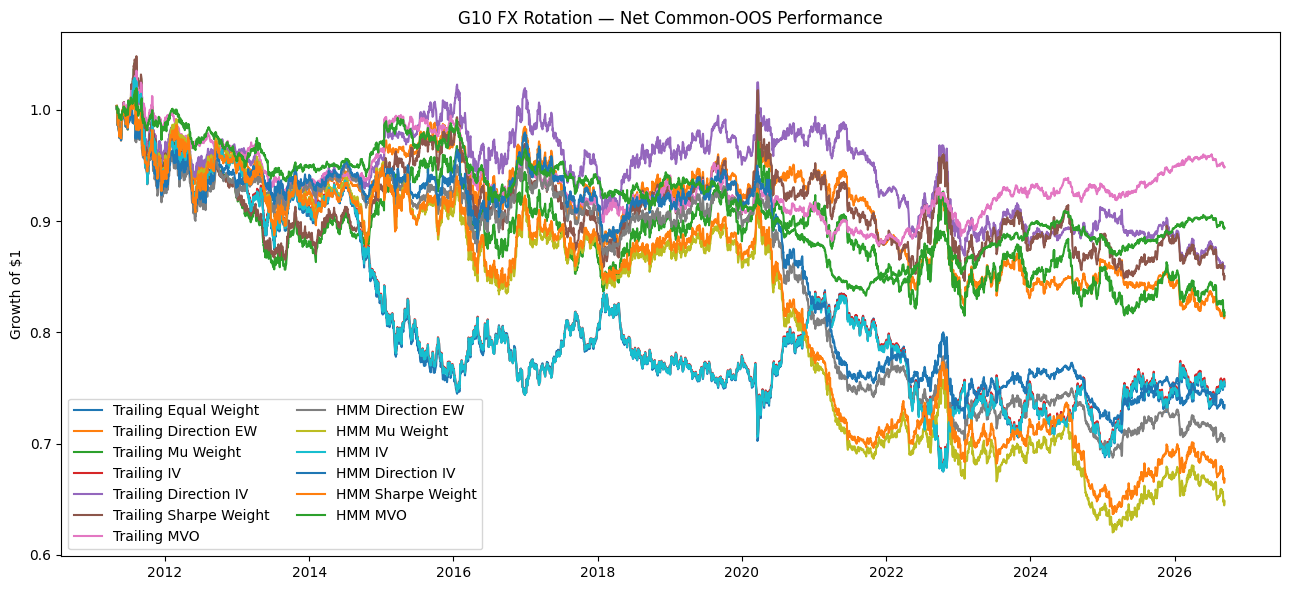

,Observed,Bootstrap Mean,2.5%,Median,97.5%,P(S > 0)
Trailing Equal Weight,-0.2336,-0.2374,-0.6733,-0.2373,0.2085,0.1496
Trailing Direction EW,-0.2243,-0.2229,-0.6781,-0.2222,0.2374,0.1684
Trailing Mu Weight,-0.1814,-0.1793,-0.6558,-0.1822,0.3084,0.2178
Trailing IV,-0.2366,-0.2402,-0.6750,-0.2403,0.2101,0.1504
Trailing Direction IV,-0.1684,-0.1667,-0.6254,-0.1662,0.3020,0.2370
Trailing Sharpe Weight,-0.1458,-0.1431,-0.6239,-0.1450,0.3460,0.2710
Trailing MVO,-0.0927,-0.0940,-0.5795,-0.0932,0.3894,0.3462
HMM Direction EW,-0.3976,-0.3979,-0.8362,-0.3998,0.0536,0.0410
HMM Mu Weight,-0.3981,-0.3967,-0.8550,-0.3986,0.0666,0.0462
HMM IV,-0.2392,-0.2428,-0.6794,-0.2424,0.2079,0.1488


In [20]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, yfinance as yf
from scipy.stats import skew, multivariate_normal
from scipy.special import logsumexp
from sklearn.covariance import LedoitWolf
from hmmlearn.hmm import GaussianHMM

TICKERS=["EURUSD=X","GBPUSD=X","AUDUSD=X","NZDUSD=X","JPY=X","CAD=X","CHF=X"]
ASSETS=["EUR","GBP","AUD","NZD","JPY","CAD","CHF"]

TRAIL=252*5
HMM_STATES=3
HMM_WINDOW=252*5
HMM_N_ITER=500
TC_BPS=5
N_BOOT=5000
BLOCK=20
SEED=42

px=yf.download(
    TICKERS,start="2000-01-01",
    auto_adjust=True,progress=False
)["Close"]

q=pd.DataFrame(index=px.index)
q["EUR"]=px["EURUSD=X"]
q["GBP"]=px["GBPUSD=X"]
q["AUD"]=px["AUDUSD=X"]
q["NZD"]=px["NZDUSD=X"]
q["JPY"]=1/px["JPY=X"]
q["CAD"]=1/px["CAD=X"]
q["CHF"]=1/px["CHF=X"]

r=q.pct_change(fill_method=None).dropna()

def l1(w):
    w=np.asarray(w,float)
    d=np.abs(w).sum()
    return w/d if d else np.zeros_like(w)

def lw(x):
    return LedoitWolf().fit(np.asarray(x)).covariance_

def dew(mu): return l1(np.sign(mu))
def muw(mu): return l1(mu)
def iv(sd): return l1(1/np.maximum(sd,1e-12))
def div(mu,sd): return l1(np.sign(mu)/np.maximum(sd,1e-12))
def sw(mu,sd): return l1(mu/np.maximum(sd,1e-12))
def mvo(mu,cov): return l1(np.linalg.pinv(cov)@mu)

def metrics(x):
    x=pd.Series(x).dropna()
    ar=x.mean()*252
    vol=x.std()*np.sqrt(252)
    sh=ar/vol if vol else np.nan
    wealth=(1+x).cumprod()
    yrs=len(x)/252
    dd=wealth/wealth.cummax()-1
    return pd.Series({
        "CAGR":wealth.iloc[-1]**(1/yrs)-1,
        "Arithmetic Return":ar,
        "Volatility":vol,
        "Sharpe":sh,
        "Skew":skew(x,bias=False),
        "Max Drawdown":dd.min()
    })

def sr(x):
    s=np.std(x,ddof=1)
    return np.mean(x)/s*np.sqrt(252) if s else np.nan

def sb(T,L,rng):
    p=1/L
    z=np.empty(T,dtype=int)
    z[0]=rng.integers(T)
    for t in range(1,T):
        z[t]=rng.integers(T) if rng.random()<p else (z[t-1]+1)%T
    return z

def fit_hmm(hist):
    a=hist.values
    mean=a.mean(0)
    sd=a.std(0,ddof=1)
    sd=np.where(sd>0,sd,1)
    X=(a-mean)/sd

    model=GaussianHMM(
        n_components=HMM_STATES,
        covariance_type="full",
        n_iter=HMM_N_ITER,
        random_state=SEED
    ).fit(X)

    gamma=model.predict_proba(X)
    gc=lw(a)
    means=[]
    covs=[]

    for k in range(HMM_STATES):
        p=gamma[:,k]
        mu=np.average(a,axis=0,weights=p)
        xc=a-mu
        wcov=(xc*p[:,None]).T@xc/p.sum()
        means.append(mu)
        covs.append(.5*wcov+.5*gc)

    return {
        "model":model,
        "alpha":gamma[-1],
        "mean":mean,
        "sd":sd,
        "means":np.asarray(means),
        "covs":np.asarray(covs)
    }

def update_hmm(state,obs):
    model=state["model"]
    z=(obs-state["mean"])/state["sd"]
    prior=state["alpha"]@model.transmat_

    ll=np.array([
        multivariate_normal.logpdf(
            z,
            mean=model.means_[k],
            cov=model.covars_[k],
            allow_singular=True
        )
        for k in range(HMM_STATES)
    ])

    p=np.log(np.clip(prior,1e-300,None))+ll
    state["alpha"]=np.exp(p-logsumexp(p))

def hmm_fc(state,h=1):
    p=state["alpha"].copy()
    mus=[]
    seconds=[]

    for _ in range(h):
        p=p@state["model"].transmat_
        mu=np.sum(p[:,None]*state["means"],axis=0)
        sec=sum(
            p[k]*(state["covs"][k]+np.outer(state["means"][k],state["means"][k]))
            for k in range(HMM_STATES)
        )
        mus.append(mu)
        seconds.append(sec)

    mu=np.mean(mus,axis=0)
    cov=np.mean(seconds,axis=0)-np.outer(mu,mu)
    cov=(cov+cov.T)/2

    e=np.linalg.eigvalsh(cov)
    if e.min()<1e-12:
        cov+=np.eye(len(mu))*(1e-12-e.min())

    return mu,cov

BASE=[
    "Equal Weight",
    "Direction EW",
    "Mu Weight",
    "IV",
    "Direction IV",
    "Sharpe Weight",
    "MVO"
]

TRAIL_NAMES=["Trailing "+s for s in BASE]
HMM_NAMES=["HMM "+s for s in BASE[1:]]
HMM21_NAMES=["HMM21 "+s for s in BASE[1:]]
STRATS=TRAIL_NAMES+HMM_NAMES

gross=pd.DataFrame(np.nan,index=r.index,columns=STRATS)
gross21=pd.DataFrame(np.nan,index=r.index,columns=HMM21_NAMES)

weights={s:{} for s in STRATS}
weights21={s:{} for s in HMM21_NAMES}

periods=r.index.to_period("M")
state=None
last_q=None

for month in sorted(periods.unique()):
    dates=r.index[periods==month]
    if not len(dates):
        continue

    pos=r.index.get_loc(dates[0])
    if pos==0:
        continue

    info=r.index[pos-1]
    hist=r.loc[:info].tail(TRAIL)
    R=r.loc[dates,ASSETS].values

    w=np.ones(len(ASSETS))/len(ASSETS)
    weights["Trailing Equal Weight"][month]=w
    gross.loc[dates,"Trailing Equal Weight"]=R@w

    if len(hist)>=TRAIL:
        mu=hist.mean().values
        sd=hist.std().values
        cov=lw(hist.values)

        W=[
            dew(mu),
            muw(mu),
            iv(sd),
            div(mu,sd),
            sw(mu,sd),
            mvo(mu,cov)
        ]

        for s,w in zip(TRAIL_NAMES[1:],W):
            weights[s][month]=w
            gross.loc[dates,s]=R@w

    qtr=(month.year,month.quarter)

    if qtr!=last_q and len(hist)>=HMM_WINDOW:
        state=fit_hmm(hist.tail(HMM_WINDOW))
        last_q=qtr

    if state is not None:
        mu,cov=hmm_fc(state,1)
        sd=np.sqrt(np.diag(cov))

        mu21,cov21=hmm_fc(state,21)
        sd21=np.sqrt(np.diag(cov21))

        W=[
            dew(mu),muw(mu),iv(sd),
            div(mu,sd),sw(mu,sd),mvo(mu,cov)
        ]

        W21=[
            dew(mu21),muw(mu21),iv(sd21),
            div(mu21,sd21),sw(mu21,sd21),mvo(mu21,cov21)
        ]

        for s,w in zip(HMM_NAMES,W):
            weights[s][month]=w
            gross.loc[dates,s]=R@w

        for s,w in zip(HMM21_NAMES,W21):
            weights21[s][month]=w
            gross21.loc[dates,s]=R@w

        for obs in R:
            update_hmm(state,obs)

def apply_cost(gross,weights):
    net=gross.copy()
    turn=pd.DataFrame(0.,index=gross.index,columns=gross.columns)

    for s in gross.columns:
        prev=np.zeros(len(ASSETS))

        for month in sorted(gross.index.to_period("M").unique()):
            dates=gross.index[gross.index.to_period("M")==month]

            if month not in weights[s]:
                continue

            cur=np.asarray(weights[s][month])
            t=np.abs(cur-prev).sum()

            turn.loc[dates[0],s]=t
            net.loc[dates[0],s]-=t*TC_BPS/1e4
            prev=cur

    return net,turn

net,turn=apply_cost(gross,weights)
net21,turn21=apply_cost(gross21,weights21)

common=gross[STRATS].dropna().index
G=gross.loc[common]
N=net.loc[common]
T=turn.loc[common]

res=pd.DataFrame({s:metrics(N[s]) for s in STRATS}).T
gres=pd.DataFrame({s:metrics(G[s]) for s in STRATS}).T

years=len(common)/252
months=common.to_period("M").nunique()

cost_summary=pd.DataFrame({
    "Gross Sharpe":gres["Sharpe"],
    "Net Sharpe":res["Sharpe"],
    "Avg Monthly Turnover":T.sum()/months,
    "Annualized Turnover":T.sum()/years
})

display(res.round(4))
display(cost_summary.round(4))

rob_idx=gross21.dropna().index.intersection(common)

rob=pd.DataFrame({
    s:metrics(net21.loc[rob_idx,s])
    for s in HMM21_NAMES
}).T

display(rob.round(4))

wealth=(1+N).cumprod()

plt.figure(figsize=(13,6))
for s in STRATS:
    plt.plot(wealth.index,wealth[s],label=s)
plt.ylabel("Growth of $1")
plt.title("G10 FX Rotation — Net Common-OOS Performance")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

rng=np.random.default_rng(SEED)
A=N.values
boot=np.empty((N_BOOT,len(STRATS)))

for b in range(N_BOOT):
    ii=sb(len(A),BLOCK,rng)
    z=A[ii]

    for j in range(len(STRATS)):
        boot[b,j]=sr(z[:,j])

boot=pd.DataFrame(boot,columns=STRATS)

bs=pd.DataFrame({
    "Observed":res["Sharpe"],
    "Bootstrap Mean":boot.mean(),
    "2.5%":boot.quantile(.025),
    "Median":boot.median(),
    "97.5%":boot.quantile(.975),
    "P(S > 0)":(boot>0).mean()
})

display(bs.round(4))